# 05 Exploratory Analysis of Stylometric Features

## Objective

Here I explore whether different large language models show measurable writing-style differences after generating responses to the same controlled prompt set.

The analysis uses the stylometric feature dataset created from the cleaned model outputs. The dataset contains 1,000 generated texts:

- 200 outputs from GPT
- 200 outputs from Claude
- 200 outputs from DeepSeek
- 200 outputs from Gemini
- 200 outputs from Mistral

Each model responded to the same 200 prompts across four genres: Narrative, Descriptive, Argumentative, and Dialogue.

## Research Question

Can stylometric features distinguish texts generated by different LLMs?

## Purpose 

To perform exploratory analysis before formal statistical testing and classification. It checks:

1. whether the dataset is balanced;
2. whether stylometric features differ by model family;
3. which features show the strongest between-model variation;
4. whether differences appear in sentence structure, punctuation, lexical diversity, readability, and marker usage.

In [17]:
from pathlib import Path
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

FEATURE_PATH = PROJECT_ROOT / "data" / "features" / "final" / "stylometric_features.csv"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)

print("Project root:", PROJECT_ROOT)
print("Feature path:", FEATURE_PATH)

Project root: /Users/violaawor/Desktop/LLM-sytlometric
Feature path: /Users/violaawor/Desktop/LLM-sytlometric/data/features/final/stylometric_features.csv


## 1. Load the stylometric feature dataset

The feature dataset was created by the modular extraction script `scripts/extract_features.py`. Each row represents one model-generated text, and each `stylo_` column represents a numerical writing-style feature.

The notebook starts by loading the final feature file and identifying all stylometric feature columns.

In [18]:
features_df = pd.read_csv(FEATURE_PATH)

feature_columns = [col for col in features_df.columns if col.startswith("stylo_")]

print("Dataset shape:", features_df.shape)
print("Number of stylometric features:", len(feature_columns))

features_df.head()

Dataset shape: (1000, 55)
Number of stylometric features: 43


,text_id,prompt_id,genre,theme,model_family,model_name,provider,temperature,max_tokens,date_generated,clean_output_text,clean_word_count,stylo_word_count,stylo_character_count,stylo_sentence_count,stylo_avg_word_length,stylo_avg_sentence_length,stylo_sentence_length_std,stylo_sentence_length_min,stylo_sentence_length_max,stylo_sentence_length_range,stylo_short_sentence_ratio,stylo_long_sentence_ratio,stylo_punctuation_count,stylo_comma_count,stylo_period_count,stylo_question_mark_count,stylo_exclamation_count,stylo_semicolon_count,stylo_colon_count,stylo_dash_count,stylo_quote_count,stylo_uppercase_word_count,stylo_titlecase_word_count,stylo_uppercase_char_ratio,stylo_type_token_ratio,stylo_hapax_legomena_ratio,stylo_repeated_word_ratio,stylo_yules_k,stylo_simpson_diversity,stylo_honores_r,stylo_mattr_50,stylo_function_word_count,stylo_function_word_ratio,stylo_ai_marker_count,stylo_ai_marker_ratio,stylo_transition_marker_count,stylo_transition_marker_ratio,stylo_hedging_marker_count,stylo_hedging_marker_ratio,stylo_punctuation_per_100_words,stylo_comma_per_100_words,stylo_period_per_100_words,stylo_flesch_reading_ease,stylo_gunning_fog
0,GPT_gpt-4o-mini_NAR_001,NAR_001,Narrative,academic,GPT,gpt-4o-mini,OpenAI,0.7,450,2026-06-24T15:26:04,"As the sun dipped below the horizon, casting a...",217,217,1379,12,5.202765,18.083333,6.383029,9,28,19,0.166667,0.250000,33,19,12,0,0,0,1,1,0,1,15,0.015943,0.714286,0.594470,0.167742,76.026248,0.992362,3207.246499,0.889405,84,0.387097,2,0.009217,2,0.009217,0,0.000000,15.207373,8.755760,5.529954,39.943089,14.422273
1,GPT_gpt-4o-mini_NAR_002,NAR_002,Narrative,academic,GPT,gpt-4o-mini,OpenAI,0.7,450,2026-06-24T15:26:12,Sophia stared at the long list of project topi...,209,209,1337,12,5.234450,17.416667,5.361255,9,26,17,0.083333,0.166667,32,17,11,1,0,0,2,1,0,0,14,0.012797,0.684211,0.583732,0.146853,96.609510,0.990293,3637.875229,0.873125,82,0.392344,0,0.000000,3,0.014354,2,0.009569,15.311005,8.133971,5.263158,42.220241,15.004944
2,GPT_gpt-4o-mini_NAR_003,NAR_003,Narrative,academic,GPT,gpt-4o-mini,OpenAI,0.7,450,2026-06-24T15:26:19,Dr. Elara Grant spent countless hours meticulo...,204,204,1279,9,5.098039,22.666667,12.156388,1,51,50,0.111111,0.333333,38,15,10,1,0,1,1,3,7,0,16,0.015385,0.691176,0.568627,0.177305,81.699346,0.991790,2999.419677,0.874065,75,0.367647,1,0.004902,0,0.000000,2,0.009804,18.627451,7.352941,4.901961,38.266569,17.105882
3,GPT_gpt-4o-mini_NAR_004,NAR_004,Narrative,academic,GPT,gpt-4o-mini,OpenAI,0.7,450,2026-06-24T15:26:23,"As the clock ticked ominously toward midnight,...",207,207,1287,11,5.062802,18.818182,3.588319,14,26,12,0.000000,0.090909,32,21,11,0,0,0,0,2,0,0,12,0.011450,0.666667,0.555556,0.166667,113.888305,0.988556,3199.631276,0.840759,85,0.410628,0,0.000000,1,0.004831,0,0.000000,15.458937,10.144928,5.314010,46.734545,14.290558
4,GPT_gpt-4o-mini_NAR_005,NAR_005,Narrative,academic,GPT,gpt-4o-mini,OpenAI,0.7,450,2026-06-24T15:26:27,As the late autumn sun filtered through the du...,208,208,1320,12,5.187500,17.333333,7.226494,6,33,27,0.166667,0.166667,32,16,12,0,0,1,1,2,0,2,13,0.017609,0.677885,0.567308,0.163121,113.258136,0.988619,3272.142910,0.868428,84,0.403846,2,0.009615,0,0.000000,1,0.004808,15.384615,7.692308,5.769231,40.378205,15.779487


## 2. Dataset balance checks

Before comparing model writing styles, the dataset must be checked for balance. A balanced corpus is important because unequal model or genre distributions could bias the analysis.

The expected design is:

- 5 model families;
- 200 texts per model family;
- 4 genres;
- 250 texts per genre;
- 50 texts per model family per genre.

In [19]:
print("Rows by model family:")
display(features_df["model_family"].value_counts().sort_index())

print("Rows by genre:")
display(features_df["genre"].value_counts().sort_index())

print("Model family × genre:")
balance_table = pd.crosstab(features_df["model_family"], features_df["genre"])
display(balance_table)

Rows by model family:


model_family
Claude      200
DeepSeek    200
GPT         200
Gemini      200
Mistral     200
Name: count, dtype: int64

Rows by genre:


genre
Argumentative    250
Descriptive      250
Dialogue         250
Narrative        250
Name: count, dtype: int64

Model family × genre:


genre,Argumentative,Descriptive,Dialogue,Narrative
model_family,,,,
Claude,50,50,50,50
DeepSeek,50,50,50,50
GPT,50,50,50,50
Gemini,50,50,50,50
Mistral,50,50,50,50


### Interpretation

The balance checks confirm that my corpus has the exact structure required for a fair stylometric comparison. Each model family contributes 200 generated texts, and each genre contributes 250 texts. The cross-tabulation also confirms that every model generated 50 texts in each genre: Argumentative, Descriptive, Dialogue, and Narrative.

This is important because I am not comparing models on an uneven sample. If one model had more dialogue texts or more argumentative texts than another, observed differences could reflect genre effects rather than model-level writing style. Here, the design is controlled: any systematic differences observed later are more plausibly linked to model-family style rather than dataset imbalance.


In [20]:
missing_features = features_df[feature_columns].isna().sum()
missing_features = missing_features[missing_features > 0]

constant_features = [
    col for col in feature_columns
    if features_df[col].nunique(dropna=False) <= 1
]

print("Missing feature values:")
display(missing_features if not missing_features.empty else "No missing feature values found.")

print("Constant features:")
display(constant_features if constant_features else "No constant features found.")

Missing feature values:


'No missing feature values found.'

Constant features:


'No constant features found.'

### Interpretation

The feature-quality check shows that there are no missing values in the stylometric feature columns and no constant features. This is a strong result because it means every generated text has a complete numerical representation, and every extracted feature varies across the corpus.

For the next phases of the project, this matters because statistical tests and classification models require a clean feature matrix. A feature with missing values would need imputation or removal, while a constant feature would contribute no discriminatory information. Since neither problem appears here, all 43 stylometric features can be retained for exploratory analysis.


In [21]:
feature_families = {
    "Length and structure": [
        "stylo_word_count",
        "stylo_character_count",
        "stylo_sentence_count",
        "stylo_avg_word_length",
        "stylo_avg_sentence_length",
        "stylo_sentence_length_std",
        "stylo_sentence_length_min",
        "stylo_sentence_length_max",
        "stylo_sentence_length_range",
        "stylo_short_sentence_ratio",
        "stylo_long_sentence_ratio",
    ],
    "Punctuation": [
        "stylo_punctuation_count",
        "stylo_comma_count",
        "stylo_period_count",
        "stylo_question_mark_count",
        "stylo_exclamation_count",
        "stylo_semicolon_count",
        "stylo_colon_count",
        "stylo_dash_count",
        "stylo_quote_count",
        "stylo_punctuation_per_100_words",
        "stylo_comma_per_100_words",
        "stylo_period_per_100_words",
    ],
    "Casing": [
        "stylo_uppercase_word_count",
        "stylo_titlecase_word_count",
        "stylo_uppercase_char_ratio",
    ],
    "Lexical diversity": [
        "stylo_type_token_ratio",
        "stylo_hapax_legomena_ratio",
        "stylo_repeated_word_ratio",
        "stylo_yules_k",
        "stylo_simpson_diversity",
        "stylo_honores_r",
        "stylo_mattr_50",
    ],
    "Markers and function words": [
        "stylo_function_word_count",
        "stylo_function_word_ratio",
        "stylo_ai_marker_count",
        "stylo_ai_marker_ratio",
        "stylo_transition_marker_count",
        "stylo_transition_marker_ratio",
        "stylo_hedging_marker_count",
        "stylo_hedging_marker_ratio",
    ],
    "Readability": [
        "stylo_flesch_reading_ease",
        "stylo_gunning_fog",
    ],
}

for family, cols in feature_families.items():
    available = [col for col in cols if col in features_df.columns]
    print(f"{family}: {len(available)} features")

Length and structure: 11 features
Punctuation: 12 features
Casing: 3 features
Lexical diversity: 7 features
Markers and function words: 8 features
Readability: 2 features


## 3. Descriptive statistics by model family

This section compares average stylometric values across the five model families. These descriptive statistics give an initial view of whether models differ in measurable writing patterns.

The table below shows mean values by model family.

In [22]:
#Model means
model_means = (
    features_df.groupby("model_family")[feature_columns]
    .mean()
    .round(3)
)

display(model_means)

,stylo_word_count,stylo_character_count,stylo_sentence_count,stylo_avg_word_length,stylo_avg_sentence_length,stylo_sentence_length_std,stylo_sentence_length_min,stylo_sentence_length_max,stylo_sentence_length_range,stylo_short_sentence_ratio,stylo_long_sentence_ratio,stylo_punctuation_count,stylo_comma_count,stylo_period_count,stylo_question_mark_count,stylo_exclamation_count,stylo_semicolon_count,stylo_colon_count,stylo_dash_count,stylo_quote_count,stylo_uppercase_word_count,stylo_titlecase_word_count,stylo_uppercase_char_ratio,stylo_type_token_ratio,stylo_hapax_legomena_ratio,stylo_repeated_word_ratio,stylo_yules_k,stylo_simpson_diversity,stylo_honores_r,stylo_mattr_50,stylo_function_word_count,stylo_function_word_ratio,stylo_ai_marker_count,stylo_ai_marker_ratio,stylo_transition_marker_count,stylo_transition_marker_ratio,stylo_hedging_marker_count,stylo_hedging_marker_ratio,stylo_punctuation_per_100_words,stylo_comma_per_100_words,stylo_period_per_100_words,stylo_flesch_reading_ease,stylo_gunning_fog
model_family,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Claude,209.850,1523.975,14.715,6.070,15.038,5.237,6.725,25.550,18.825,0.238,0.071,39.975,12.945,15.180,0.990,0.090,0.095,0.590,2.050,8.145,0.870,19.505,0.018,0.719,0.584,0.189,67.725,0.993,2985.810,0.899,56.055,0.267,0.500,0.002,1.93,0.009,1.390,0.007,19.191,6.181,7.264,21.282,18.024
DeepSeek,218.785,1368.000,10.955,5.087,21.561,8.473,8.005,36.785,28.780,0.160,0.373,34.195,18.230,10.995,0.655,0.000,0.500,0.620,3.790,5.060,1.025,16.225,0.018,0.695,0.577,0.171,100.653,0.990,3342.676,0.866,75.145,0.343,0.350,0.002,1.82,0.008,1.060,0.005,15.644,8.339,5.026,42.144,15.968
GPT,209.160,1364.200,12.640,5.334,18.123,5.687,9.385,29.165,19.780,0.161,0.185,34.795,16.435,12.240,1.040,0.645,0.315,0.645,1.675,5.415,0.855,17.100,0.018,0.668,0.540,0.194,101.004,0.990,2944.908,0.862,72.425,0.346,1.220,0.006,1.54,0.007,1.550,0.007,16.628,7.869,5.841,38.358,15.928
Gemini,209.650,1435.700,10.715,5.668,20.762,7.870,9.495,35.450,25.955,0.133,0.318,42.295,20.355,10.800,0.585,0.095,0.410,0.365,2.810,6.840,1.315,16.295,0.017,0.717,0.602,0.161,84.666,0.991,3588.970,0.877,64.930,0.309,1.545,0.007,1.51,0.007,1.235,0.006,20.108,9.707,5.135,22.442,19.323
Mistral,203.280,1326.720,11.525,5.363,18.816,5.886,9.885,30.165,20.280,0.130,0.199,36.195,15.680,11.820,0.870,0.125,0.205,0.415,3.795,4.130,1.135,15.950,0.018,0.705,0.580,0.179,89.124,0.991,3132.415,0.878,64.605,0.317,0.495,0.002,1.78,0.009,1.385,0.007,17.820,7.724,5.824,37.690,16.037


In [23]:
# Top between - model variation
between_model_variation = (
    features_df.groupby("model_family")[feature_columns]
    .mean()
    .var(axis=0)
    .sort_values(ascending=False)
    .reset_index()
)

between_model_variation.columns = ["feature", "between_model_variance"]

display(between_model_variation.head(15))

,feature,between_model_variance
0,stylo_honores_r,71791.446257
1,stylo_character_count,6062.683555
2,stylo_yules_k,187.662612
3,stylo_flesch_reading_ease,95.297590
4,stylo_function_word_count,56.227120
5,stylo_word_count,30.770025
6,stylo_sentence_length_max,21.535257
7,stylo_sentence_length_range,19.239242
8,stylo_punctuation_count,12.265080
9,stylo_comma_count,7.726593


### Interpretation

The model-family means already show visible stylistic differences. The strongest between-model variation appears in `stylo_honores_r`, `stylo_character_count`, `stylo_yules_k`, `stylo_flesch_reading_ease`, `stylo_function_word_count`, and several sentence-structure and punctuation features.

This is meaningful because the leading variables are not random technical fields; they are classical stylometric signals. `stylo_honores_r` captures lexical richness, `stylo_yules_k` captures lexical repetition, `stylo_flesch_reading_ease` captures readability, and the sentence-length variables capture prose rhythm. The fact that these features vary strongly across model-family means suggests that the models may be producing distinct stylistic fingerprints.

From the model means, Claude has the highest average character count at 1523.975 characters, even though its average word count is close to GPT and Gemini. This suggests that Claude tends to use longer words or more character-dense prose. DeepSeek has the highest average word count at 218.785 words and the highest function-word count at 75.145, suggesting longer and more grammatically connective outputs. Gemini has the highest punctuation count at 42.295 and the highest comma count at 20.355, suggesting a more punctuation-heavy style. Mistral has the lowest average word count at 203.280 and the lowest character count at 1326.720, making it the most compact model in this sample.


In [24]:
# Plot helper
def plot_feature_by_model(feature: str, title: str | None = None) -> None:
    """
    Plot model-family means for one stylometric feature.
    """
    summary = (
        features_df.groupby("model_family")[feature]
        .mean()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(8, 5))
    plt.bar(summary.index.tolist(), summary.tolist())
    plt.ylabel(feature)
    plt.xlabel("Model family")
    plt.title(title or f"Mean {feature} by model family")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

## 4. Length and sentence structure features

Length and sentence structure are central stylometric indicators. Even under the same 180–220 word constraint, models may differ in character density, sentence count, average sentence length, and sentence-length variability.

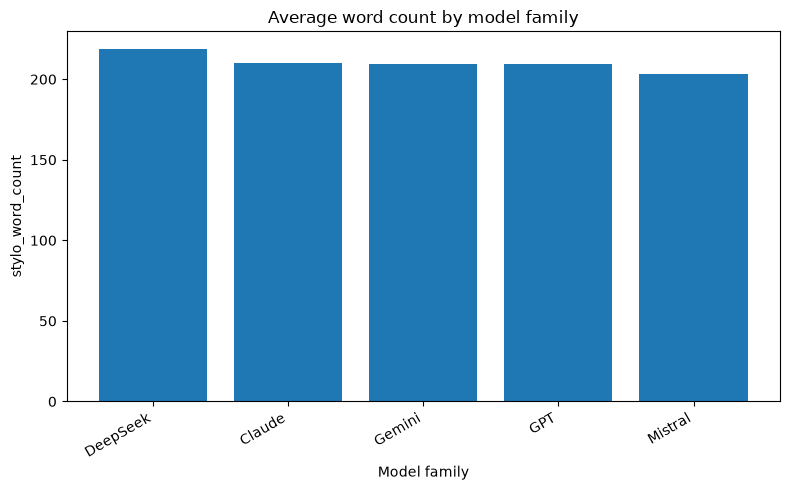

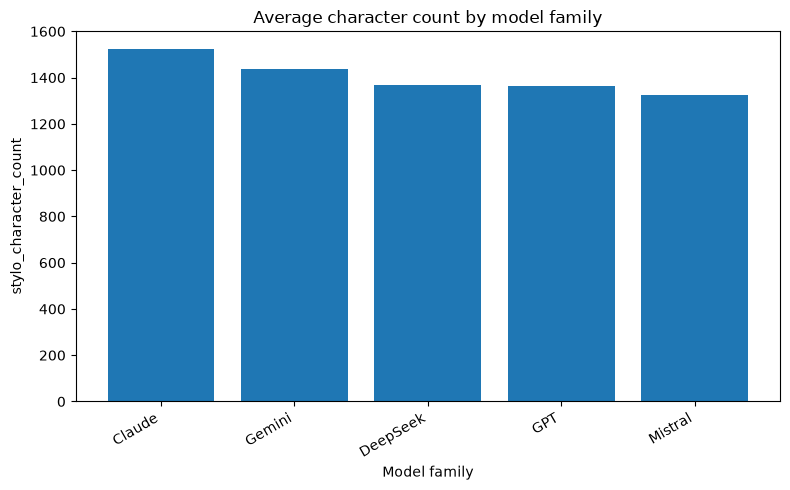

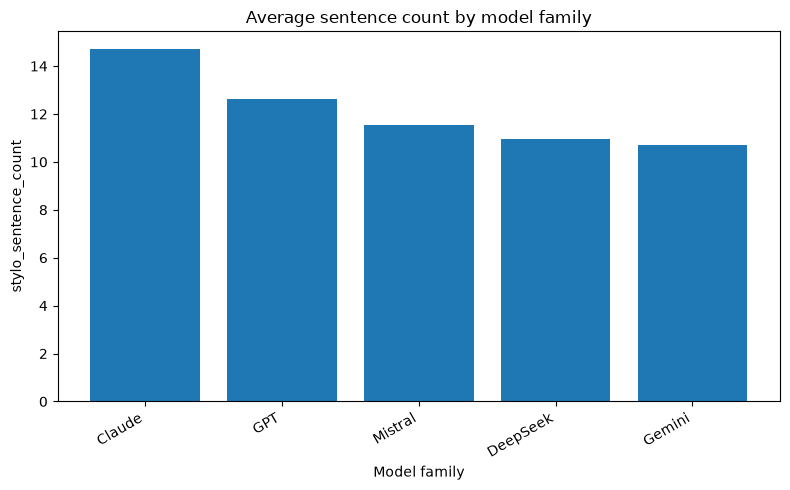

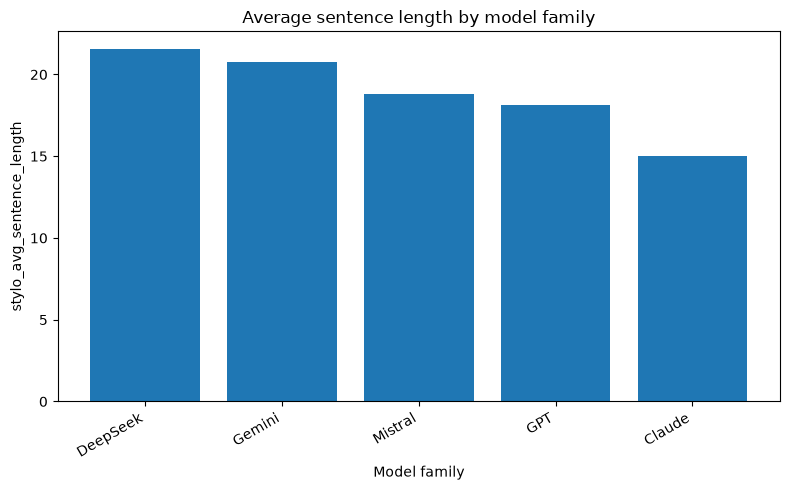

In [25]:
#Length and structure features
plot_feature_by_model("stylo_word_count", "Average word count by model family")
plot_feature_by_model("stylo_character_count", "Average character count by model family")
plot_feature_by_model("stylo_sentence_count", "Average sentence count by model family")
plot_feature_by_model("stylo_avg_sentence_length", "Average sentence length by model family")

### Interpretation

The length and sentence-structure plots show clear model-level differences despite the controlled 180–220 word generation range. DeepSeek has the highest average word count at 218.785, while Mistral has the lowest at 203.280. This indicates that DeepSeek tends to use nearly the full allowed word range, whereas Mistral writes more compactly.

The character-count plot shows a different pattern: Claude has the highest average character count at 1523.975, even though its word count is not the highest. I interpret this as evidence that Claude tends to produce longer words or more character-dense phrasing. Mistral has the lowest character count, which reinforces its compact style.

The sentence-count and average-sentence-length plots are especially important for stylometry. Claude has the highest average sentence count at 14.715 and the shortest average sentence length at 15.038 words, suggesting a more segmented rhythm. DeepSeek has only 10.955 sentences on average but the longest average sentence length at 21.561 words, suggesting longer, more extended sentence construction. Gemini follows a similar long-sentence pattern with an average sentence length of 20.762. These differences show that the models vary not only in length, but also in sentence rhythm and prose structure.


## 5. Punctuation features

Punctuation style can reveal differences in sentence rhythm, clause structure, and formatting preferences. This section compares punctuation count, comma use, period use, and punctuation density per 100 words.

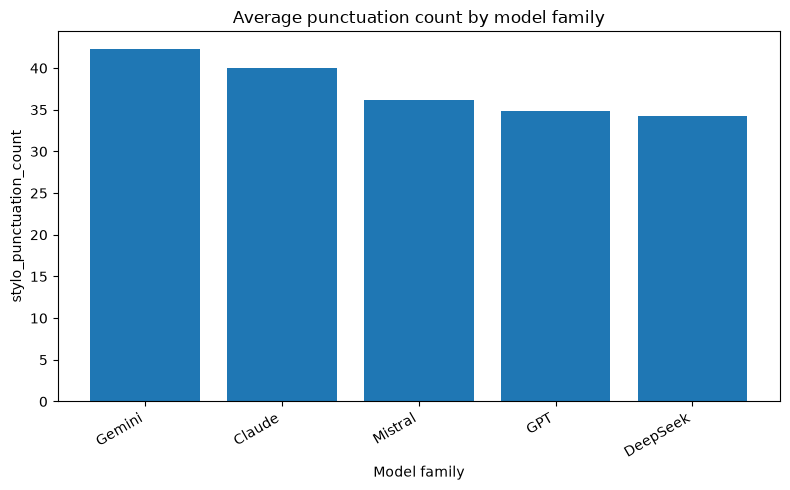

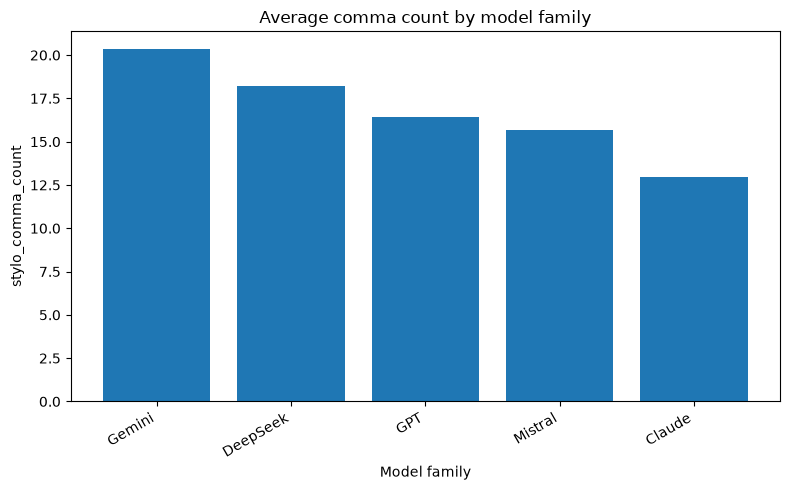

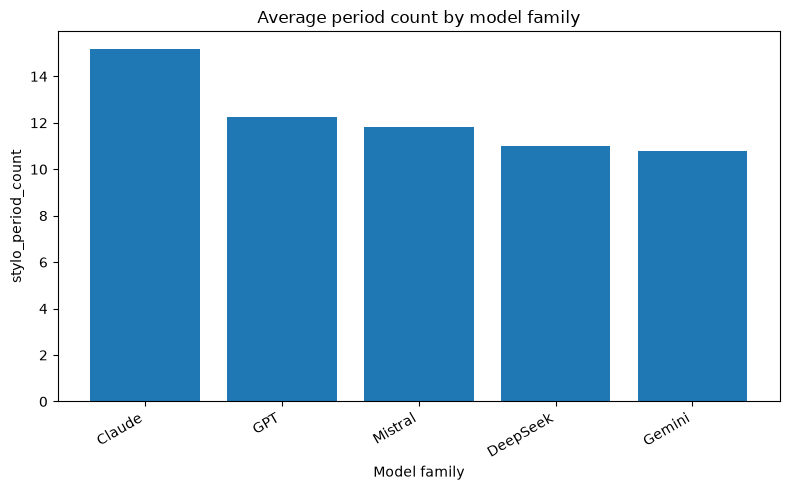

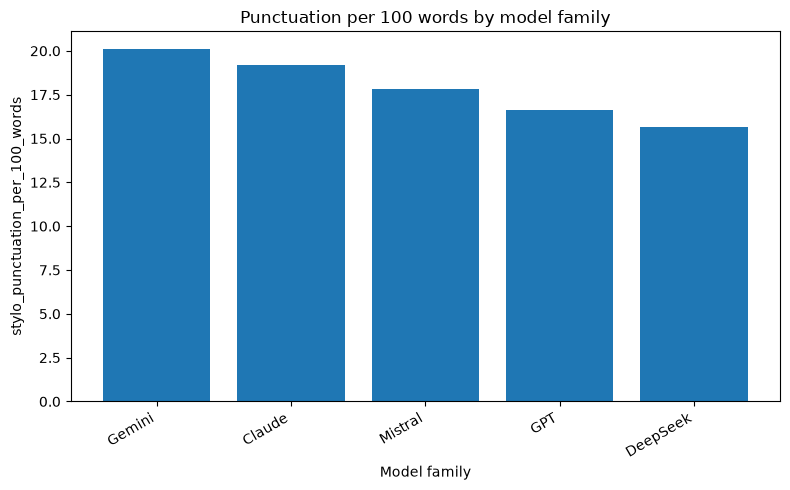

In [26]:
plot_feature_by_model("stylo_punctuation_count", "Average punctuation count by model family")
plot_feature_by_model("stylo_comma_count", "Average comma count by model family")
plot_feature_by_model("stylo_period_count", "Average period count by model family")
plot_feature_by_model("stylo_punctuation_per_100_words", "Punctuation per 100 words by model family")

### Interpretation

The punctuation plots show that punctuation use differs noticeably by model family. Gemini has the highest average punctuation count at 42.295 and the highest comma count at 20.355. This suggests that Gemini tends to produce more clause-heavy or syntactically layered prose, especially through comma-separated phrases.

Claude has the highest average period count at 15.180, which matches the earlier observation that Claude has the highest sentence count and shorter average sentences. This suggests a more segmented sentence style. DeepSeek has a relatively high comma count at 18.230 but a lower period count at 10.995, which supports the interpretation that it writes longer sentences with more internal clauses.

Mistral has relatively moderate punctuation overall, but it has the highest dash count at 3.795, very close to DeepSeek at 3.790. This may indicate a stronger tendency to use dash-based interruption or elaboration. Overall, punctuation is functioning as a stylistic signal here because models differ in how they organize clauses and sentence boundaries.


## 6. Lexical diversity features

Lexical diversity features measure vocabulary richness and repetition. This section examines type-token ratio, hapax legomena ratio, Yule's K, Simpson diversity, Honore's R, and MATTR.

These features help identify whether some models use broader vocabularies, repeat words more often, or generate more lexically varied prose.

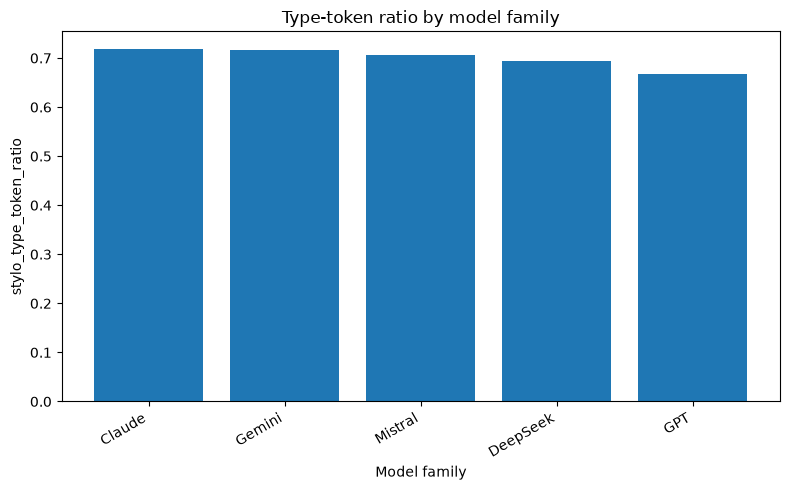

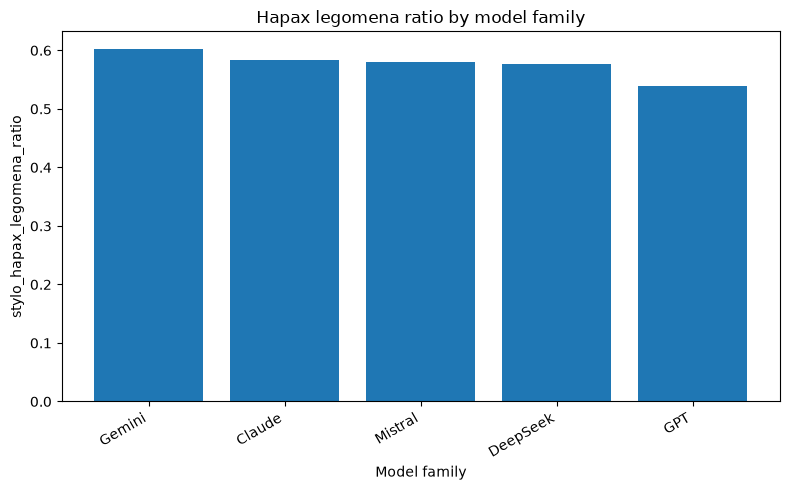

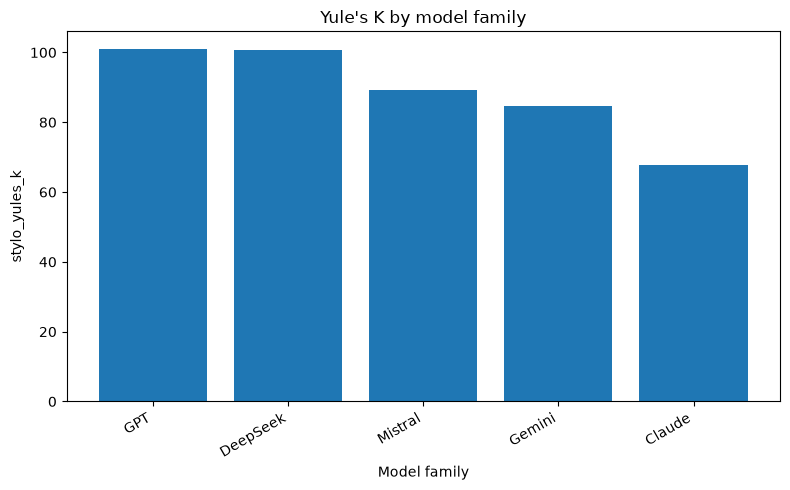

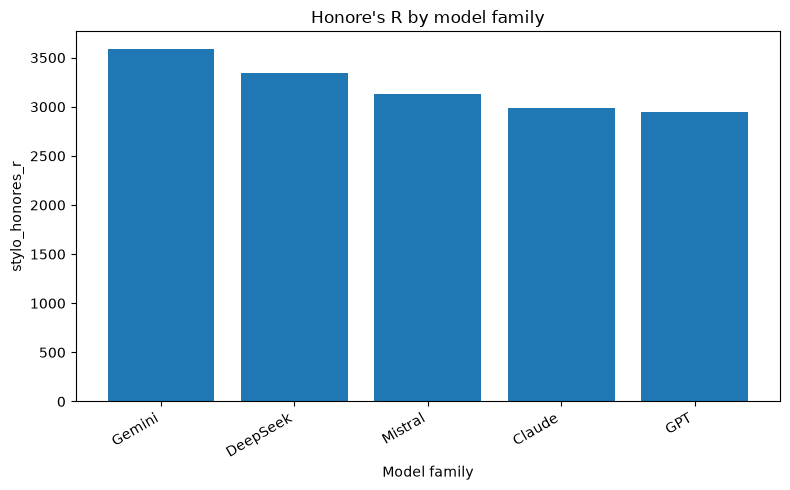

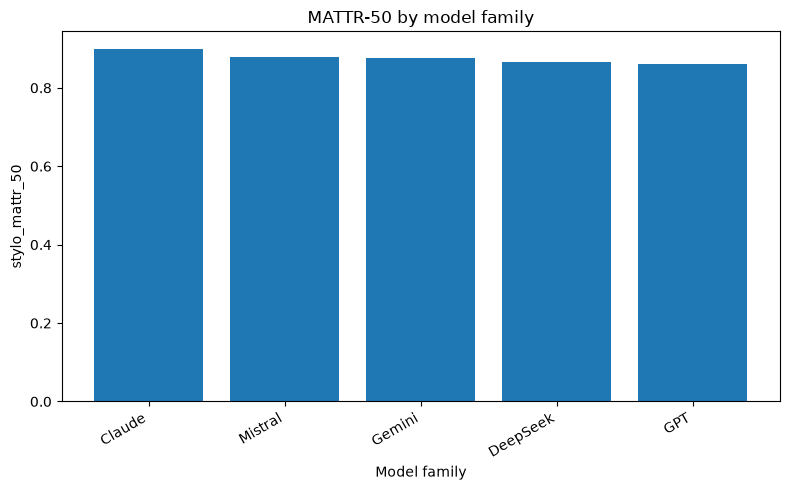

In [27]:
#Lexical diversity plots
plot_feature_by_model("stylo_type_token_ratio", "Type-token ratio by model family")
plot_feature_by_model("stylo_hapax_legomena_ratio", "Hapax legomena ratio by model family")
plot_feature_by_model("stylo_yules_k", "Yule's K by model family")
plot_feature_by_model("stylo_honores_r", "Honore's R by model family")
plot_feature_by_model("stylo_mattr_50", "MATTR-50 by model family")

### Interpretation

The lexical diversity results suggest that the models differ in vocabulary richness and repetition. Claude has the highest type-token ratio at 0.719, while Gemini is close at 0.717. This indicates that Claude and Gemini use a relatively broad vocabulary within the 200-word constraint. GPT has the lowest type-token ratio at 0.668, suggesting comparatively more repetition or less lexical variety.

The hapax legomena ratio is highest for Gemini at 0.602, meaning Gemini produces the largest proportion of words that occur only once in a text. This supports the idea that Gemini’s outputs are lexically varied.Gemini has the highest Honore’s R at 3588.970, followed by DeepSeek at 3342.676. Since Honore’s R rewards lexical richness through rare words, this reinforces Gemini as one of the most lexically rich models in this sample.

Yule’s K is highest for GPT at 101.004 and DeepSeek at 100.653, indicating stronger lexical repetition compared with Claude, whose Yule’s K is much lower at 67.725. MATTR is highest for Claude at 0.899 and lowest for GPT at 0.862. Taken together, the lexical features suggest that Claude and Gemini show greater lexical variety, while GPT and DeepSeek show relatively more repetition.


## 7. Function words, transition markers, hedging, and AI-style markers

Function words and discourse markers are useful in stylometry because they often reflect unconscious style patterns. This section compares function-word ratios, transition markers, hedging markers, and selected AI-style marker usage.

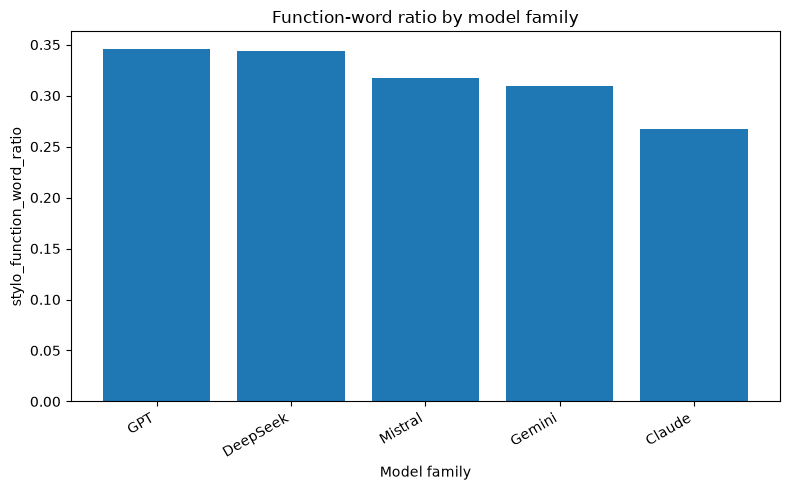

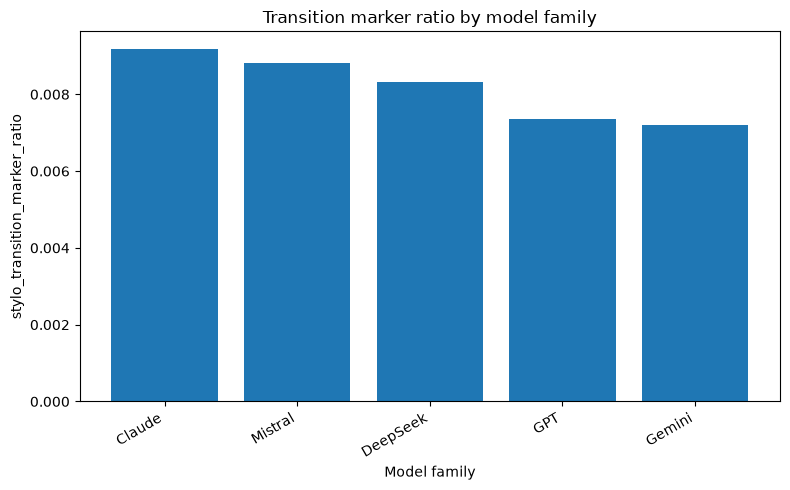

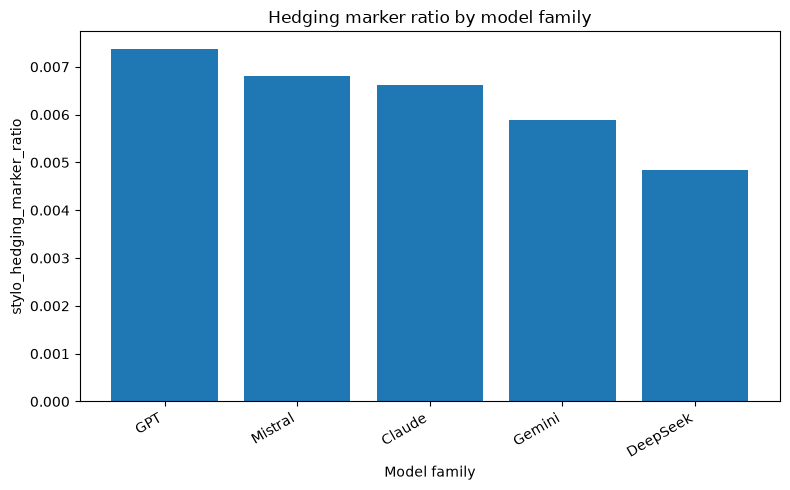

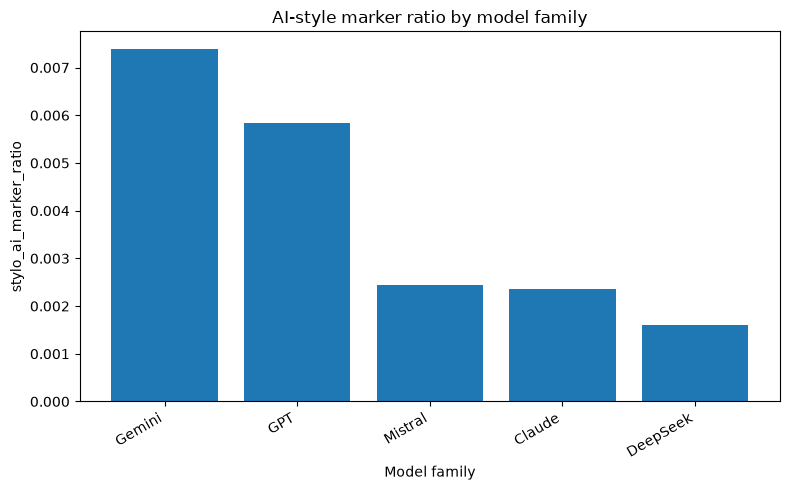

In [28]:
plot_feature_by_model("stylo_function_word_ratio", "Function-word ratio by model family")
plot_feature_by_model("stylo_transition_marker_ratio", "Transition marker ratio by model family")
plot_feature_by_model("stylo_hedging_marker_ratio", "Hedging marker ratio by model family")
plot_feature_by_model("stylo_ai_marker_ratio", "AI-style marker ratio by model family")

### Interpretation

The marker and function-word plots show important discourse-level differences. DeepSeek has the highest average function-word count at 75.145 and the highest function-word ratio at 0.343, with GPT close behind at 0.346 for the ratio. This suggests that DeepSeek and GPT rely more heavily on grammatical connector words such as articles, prepositions, pronouns, and auxiliary verbs.

AI-style marker use is highest for Gemini, with an average marker count of 1.545 and marker ratio of 0.007. GPT follows with 1.220. Claude, DeepSeek, and Mistral use fewer of these selected AI-associated terms. This suggests that Gemini and GPT may more frequently use polished or formulaic expressions captured by the AI-style marker list.

Transition-marker use is relatively similar across models, but Claude has the highest average transition count at 1.93, suggesting slightly stronger explicit discourse linking. Hedging markers are highest for GPT at 1.550, followed by Claude and Mistral. This may indicate that GPT uses slightly more cautious or qualifying language. These marker patterns are useful because discourse habits can support model-family identification beyond simple length or punctuation.


## 8. Readability features

Readability features approximate how difficult or fluent the generated prose is. This section compares Flesch Reading Ease and Gunning Fog across model families.

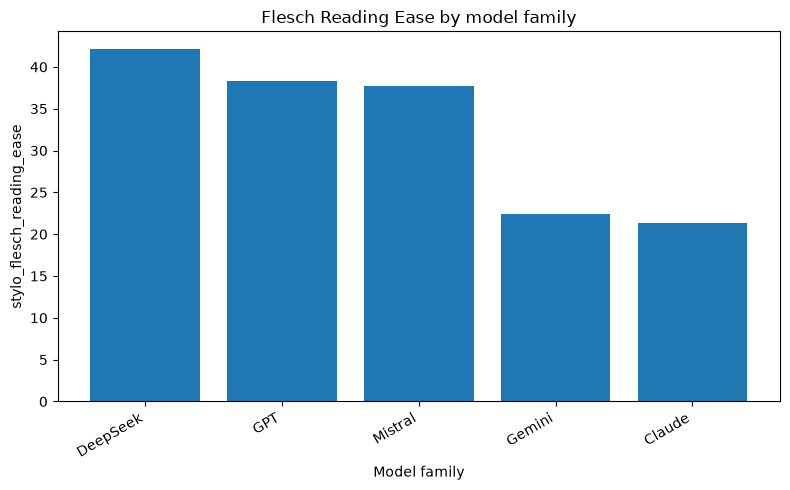

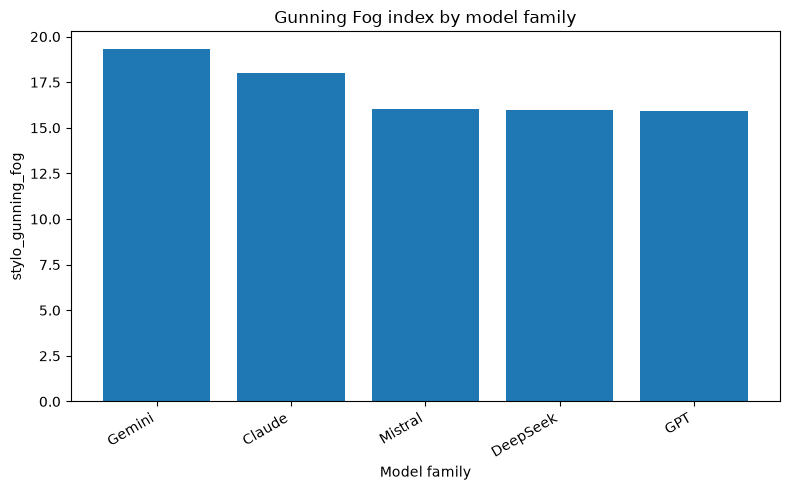

In [29]:
plot_feature_by_model("stylo_flesch_reading_ease", "Flesch Reading Ease by model family")
plot_feature_by_model("stylo_gunning_fog", "Gunning Fog index by model family")

### Interpretation

The readability plots show that the models differ in estimated reading difficulty. DeepSeek has the highest Flesch Reading Ease score at 42.144, followed by GPT at 38.358 and Mistral at 37.690. Higher Flesch scores indicate easier readability, so DeepSeek appears to produce the most readable prose according to this metric.

Claude and Gemini have much lower Flesch scores, at 21.282 and 22.442 respectively, suggesting denser or more complex prose. This aligns with earlier findings: Claude has the highest character count and average word length, while Gemini has high punctuation and longer sentences.

The Gunning Fog index gives a complementary view. Gemini has the highest Gunning Fog score at 19.323, followed by Claude at 18.024. DeepSeek, GPT, and Mistral are lower, around 15.9–16.0. This reinforces the interpretation that Gemini and Claude produce more complex prose, while DeepSeek, GPT, and Mistral are somewhat easier to read under this heuristic.


## 9. Correlation check

Before formal testing and classification, it is useful to inspect correlations among stylometric features. Highly correlated features may capture similar information, such as word count and character count or punctuation count and sentence count.

In [30]:
#Correlation summary
corr = features_df[feature_columns].corr(numeric_only=True).abs()

upper_triangle = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

high_corr_pairs = (
    upper_triangle.stack()
    .reset_index()
)

high_corr_pairs.columns = ["feature_1", "feature_2", "absolute_correlation"]
high_corr_pairs = high_corr_pairs.sort_values("absolute_correlation", ascending=False)

display(high_corr_pairs.head(20))

,feature_1,feature_2,absolute_correlation
1145,stylo_yules_k,stylo_simpson_diversity,1.000000
1409,stylo_ai_marker_count,stylo_ai_marker_ratio,0.998412
1585,stylo_hedging_marker_count,stylo_hedging_marker_ratio,0.998157
1497,stylo_transition_marker_count,stylo_transition_marker_ratio,0.996958
599,stylo_period_count,stylo_period_per_100_words,0.989658
511,stylo_punctuation_count,stylo_punctuation_per_100_words,0.989152
555,stylo_comma_count,stylo_comma_per_100_words,0.982057
1321,stylo_function_word_count,stylo_function_word_ratio,0.974929
1805,stylo_flesch_reading_ease,stylo_gunning_fog,0.954929
170,stylo_avg_word_length,stylo_flesch_reading_ease,0.950727


### Interpretation

The correlation table shows that several feature pairs are strongly related. `stylo_yules_k` and `stylo_simpson_diversity` have an absolute correlation of 1.000, meaning they are effectively capturing the same lexical repetition/diversity structure in this dataset. Similarly, marker counts and marker ratios are very highly correlated: AI-marker count and ratio correlate at 0.998, hedging-marker count and ratio at 0.998, and transition-marker count and ratio at 0.997.

Punctuation count and punctuation-per-100-words are also highly correlated at 0.989, and comma count and comma-per-100-words correlate at 0.982. This is expected because the texts were generated within a narrow word-count range, so raw counts and normalized rates remain very similar.

The high negative/positive relationships among readability and word/sentence variables are also expected. Flesch Reading Ease and Gunning Fog correlate at 0.955 in absolute terms, and average word length correlates strongly with Flesch Reading Ease at 0.951. This tells me that later classification models may benefit from regularization or feature selection, because several features encode overlapping stylistic information. However, for exploratory and statistical analysis, keeping them helps me understand which stylistic dimensions are most active.


In [31]:
#Save key EDA tables
TABLE_DIR = PROJECT_ROOT / "outputs" / "tables"
TABLE_DIR.mkdir(parents=True, exist_ok=True)

model_means.to_csv(TABLE_DIR / "eda_model_family_feature_means.csv")
between_model_variation.to_csv(TABLE_DIR / "eda_between_model_variation.csv", index=False)
high_corr_pairs.to_csv(TABLE_DIR / "eda_high_feature_correlations.csv", index=False)

print("Saved EDA summary tables to:", TABLE_DIR)

Saved EDA summary tables to: /Users/violaawor/Desktop/LLM-sytlometric/outputs/tables


## 10. Exploratory conclusion

This exploratory analysis shows that the stylometric feature dataset is balanced, complete, and suitable for downstream analysis. The corpus contains 1,000 model-generated texts, evenly distributed across five model families and four genres. Each model contributes 200 texts, and each model contributes exactly 50 texts per genre. There are no missing stylometric feature values and no constant features.

The exploratory results provide early evidence that LLM-generated texts may contain measurable model-specific writing patterns. The clearest differences appear in lexical richness, sentence structure, punctuation, function-word use, and readability. Claude stands out for high character density, high sentence count, and shorter sentences. DeepSeek stands out for higher word count, longer sentences, and high function-word use. Gemini stands out for high punctuation and comma use, high lexical richness, and high readability complexity. GPT shows comparatively high lexical repetition and AI-style marker use. Mistral appears more compact, with lower word and character counts and a more moderate overall profile.

The correlation analysis also shows that some features are redundant or strongly related, especially count-versus-ratio versions of the same marker features and lexical diversity measures. This does not invalidate the feature set, but it indicates that later classification models should use regularization, feature selection, or robustness checks.

At this stage, I should treat the results as exploratory rather than statistically conclusive. The patterns are strong enough to justify the next phase: formal statistical testing across model families, with multiple-comparison correction, to identify which stylometric features significantly distinguish the models.
